# 17. Simulation — Banking Scenario Analysis

## Business Case

Banks operate under uncertainty.

Management may ask:

- What happens if default rates increase?
- What if interest rates change?
- What if operating costs rise?
- What if economic conditions improve?
- How much profit could be lost under stress?
- Which loan segments are most sensitive?

These questions are not purely prediction problems.

They are **scenario analysis and simulation** problems.

The objective is to understand:

> **How does the banking portfolio behave under different assumptions about the future?**

This notebook demonstrates a practical end-to-end simulation workflow using a synthetic loan portfolio.

## 1. Simulation vs Prediction vs Optimization

### Prediction

```text
What is likely to happen?
```

Example:

```text
Probability of default = 4.2%
```

### Optimization

```text
What action should we take?
```

Example:

```text
Allocate 300 collection agents
```

### Simulation

```text
What could happen under different assumptions?
```

Example:

```text
PD +25%
LGD +10%
Interest rate +50 bps
Operating cost +8%
```

Simulation explores possible outcomes under changing assumptions.

## 2. Banking Scenario Analysis

A scenario is a coherent set of assumptions.

Example:

### Base

```text
Normal conditions
```

### Optimistic

```text
Lower PD
Lower LGD
Slightly lower operating cost
```

### Mild Stress

```text
Higher PD
Higher LGD
Higher operating cost
```

### Severe Stress

```text
Significantly higher PD
Higher LGD
Higher operating cost
Higher interest-rate environment
```

The goal is not to predict which scenario will happen.

The goal is to understand the **impact if the assumptions occur**.

## 3. Monte Carlo Simulation

Scenario analysis can be deterministic:

```text
Base
Stress
Severe Stress
```

Monte Carlo simulation goes further.

Instead of one fixed value, uncertain variables are sampled repeatedly:

```text
PD
LGD
Interest Rate
Operating Cost
        ↓
Random Draw
        ↓
Portfolio Profit
        ↓
Repeat thousands of times
        ↓
Distribution of Outcomes
```

This allows us to estimate:

- expected profit,
- downside risk,
- percentiles,
- probability of loss.

## 4. Key Banking Metrics

This notebook uses simplified portfolio economics.

### Expected Loss

```text
Expected Loss = EAD × PD × LGD
```

where:

- EAD = Exposure at Default
- PD = Probability of Default
- LGD = Loss Given Default

### Expected Interest Income

```text
Interest Income = EAD × Interest Rate
```

### Simplified Profit

```text
Profit
=
Interest Income
-
Expected Loss
-
Operating Cost
```

This is a simplified educational framework, not a complete bank P&L or regulatory capital model.

## 5. Import Libraries

This step imports the libraries used throughout the notebook — pandas and NumPy for data handling and random draws, and Matplotlib/Seaborn for visualisation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns",100)

df=pd.read_csv("bank_scenario_loan_portfolio_sample.csv")
scenarios=pd.read_csv("bank_scenario_assumptions.csv")

print("Loans:",len(df))
display(df.head())
display(scenarios)
# --- Save all outputs to the local output/ folder ---
from pathlib import Path

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


def save_plot(filename, dpi=150):
    """Save the current matplotlib figure into the output/ folder."""
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")


Loans: 5000


,Loan_ID,Customer_Segment,Loan_Type,Loan_Amount,Interest_Rate,Tenor_Months,PD_Base,LGD_Base,Annual_Operating_Cost,EAD,Expected_Loss_Base,Expected_Interest_Income,Expected_Profit_Base,Maturity_Years
0,L00001,Affluent,Consumer,2.922415e+07,0.113765,24,0.086178,0.207620,1.356272e+06,2.922415e+07,5.228896e+05,3.324687e+06,1.445525e+06,2.0
1,L00002,Mass,Mortgage,2.801570e+08,0.105111,24,0.113633,0.150000,7.343251e+06,2.801570e+08,4.775278e+06,2.944759e+07,1.732907e+07,2.0
2,L00003,Affluent,Auto,2.913529e+08,0.095588,12,0.042958,0.402721,2.882051e+06,2.913529e+08,5.040443e+06,2.784972e+07,1.992723e+07,1.0
3,L00004,Affluent,Consumer,8.407562e+07,0.094976,24,0.194102,0.219699,2.692449e+06,8.407562e+07,3.585315e+06,7.985197e+06,1.707432e+06,2.0
4,L00005,Mass,Consumer,1.774074e+08,0.085744,48,0.010000,0.219174,2.646130e+06,1.774074e+08,3.888308e+05,1.521156e+07,1.217660e+07,4.0


,Scenario,PD_Multiplier,LGD_Multiplier,Rate_Shock,Operating_Cost_Multiplier
0,Base,1.00,1.00,0.000,1.00
1,Optimistic,0.85,0.95,-0.005,0.95
2,Mild Stress,1.25,1.10,0.005,1.08
3,Severe Stress,1.70,1.25,0.010,1.20


## 6. Dataset Dictionary

Loan-level fields — balance, interest rate, default probability, segment and product — are documented, fixing the inputs that the scenario and Monte-Carlo simulations will stress.


In [2]:
dictionary=pd.DataFrame({
    "Column":[
        "Loan_ID","Customer_Segment","Loan_Type",
        "Loan_Amount","Interest_Rate","Tenor_Months",
        "PD_Base","LGD_Base","Annual_Operating_Cost",
        "EAD","Expected_Loss_Base",
        "Expected_Interest_Income","Expected_Profit_Base"
    ],
    "Meaning":[
        "Loan identifier",
        "Customer segment",
        "Loan product",
        "Original loan amount",
        "Annual interest rate",
        "Loan tenor",
        "Base probability of default",
        "Base loss given default",
        "Annual operating cost",
        "Exposure at default",
        "Base expected loss",
        "Base expected interest income",
        "Base simplified expected profit"
    ]
})
display(dictionary)

,Column,Meaning
0,Loan_ID,Loan identifier
1,Customer_Segment,Customer segment
2,Loan_Type,Loan product
3,Loan_Amount,Original loan amount
4,Interest_Rate,Annual interest rate
5,Tenor_Months,Loan tenor
6,PD_Base,Base probability of default
7,LGD_Base,Base loss given default
8,Annual_Operating_Cost,Annual operating cost
9,EAD,Exposure at default


## 7. Data Quality

Missing values and impossible values (negative balances, out-of-range rates) are checked so the simulation starts from a clean, credible portfolio.


In [3]:
print("Missing values:")
display(df.isna().sum().to_frame("Missing"))

print("Duplicate Loan IDs:",df["Loan_ID"].duplicated().sum())

display(df.describe().T)

Missing values:


,Missing
Loan_ID,0
Customer_Segment,0
Loan_Type,0
Loan_Amount,0
Interest_Rate,0
Tenor_Months,0
PD_Base,0
LGD_Base,0
Annual_Operating_Cost,0
EAD,0


Duplicate Loan IDs: 0


,count,mean,std,min,25%,50%,75%,max
Loan_Amount,5000.0,1.584487e+08,1.390494e+08,6.498936e+06,7.214645e+07,1.179923e+08,1.954044e+08,2.000000e+09
Interest_Rate,5000.0,1.057013e-01,1.796185e-02,6.000000e-02,9.328419e-02,1.055227e-01,1.180315e-01,1.600000e-01
Tenor_Months,5000.0,3.765360e+01,1.544201e+01,1.200000e+01,2.400000e+01,3.600000e+01,4.800000e+01,6.000000e+01
PD_Base,5000.0,9.988039e-02,6.525218e-02,1.000000e-02,4.986602e-02,8.818723e-02,1.358031e-01,3.500000e-01
LGD_Base,5000.0,3.048801e-01,1.293615e-01,1.500000e-01,1.936009e-01,2.841044e-01,3.887886e-01,8.434330e-01
Annual_Operating_Cost,5000.0,2.846033e+06,1.532806e+06,5.000000e+05,1.796484e+06,2.490607e+06,3.516361e+06,1.500000e+07
EAD,5000.0,1.584487e+08,1.390494e+08,6.498936e+06,7.214645e+07,1.179923e+08,1.954044e+08,2.000000e+09
Expected_Loss_Base,5000.0,4.745605e+06,6.329177e+06,2.773436e+04,1.224115e+06,2.697165e+06,5.616905e+06,7.583050e+07
Expected_Interest_Income,5000.0,1.681237e+07,1.542184e+07,5.091651e+05,7.391149e+06,1.219952e+07,2.069437e+07,2.124978e+08
Expected_Profit_Base,5000.0,9.220732e+06,1.276209e+07,-2.853731e+07,1.758004e+06,5.817863e+06,1.252350e+07,1.708576e+08


## 8. Portfolio Overview

Headline portfolio metrics — total exposure, average rate and baseline expected loss — are computed. These form the reference point every scenario is compared against.


In [4]:
portfolio_summary=pd.DataFrame({
    "Metric":[
        "Loans",
        "Total EAD",
        "Average Loan",
        "Expected Loss",
        "Interest Income",
        "Operating Cost",
        "Expected Profit"
    ],
    "Value":[
        len(df),
        df["EAD"].sum(),
        df["EAD"].mean(),
        df["Expected_Loss_Base"].sum(),
        df["Expected_Interest_Income"].sum(),
        df["Annual_Operating_Cost"].sum(),
        df["Expected_Profit_Base"].sum()
    ]
})

display(portfolio_summary)

,Metric,Value
0,Loans,5.000000e+03
1,Total EAD,7.922436e+11
2,Average Loan,1.584487e+08
3,Expected Loss,2.372802e+10
4,Interest Income,8.406185e+10
5,Operating Cost,1.423017e+10
6,Expected Profit,4.610366e+10


## 9. Portfolio by Loan Type

Exposure and expected loss are broken down by loan product, showing which products dominate the portfolio's risk contribution.


In [5]:
loan_type=(
    df.groupby("Loan_Type")
      .agg(
          Loans=("Loan_ID","count"),
          EAD=("EAD","sum"),
          Expected_Loss=("Expected_Loss_Base","sum"),
          Profit=("Expected_Profit_Base","sum")
      )
      .reset_index()
)

display(loan_type.round(0))

,Loan_Type,Loans,EAD,Expected_Loss,Profit
0,Auto,888,1.370207e+11,3.979767e+09,8.111312e+09
1,Consumer,2106,3.337755e+11,1.014529e+10,1.922351e+10
2,Mortgage,1276,2.016583e+11,6.067351e+09,1.174123e+10
3,Working Capital,730,1.197890e+11,3.535611e+09,7.027609e+09


Saved: output/9-portfolio-by-loan-type.png


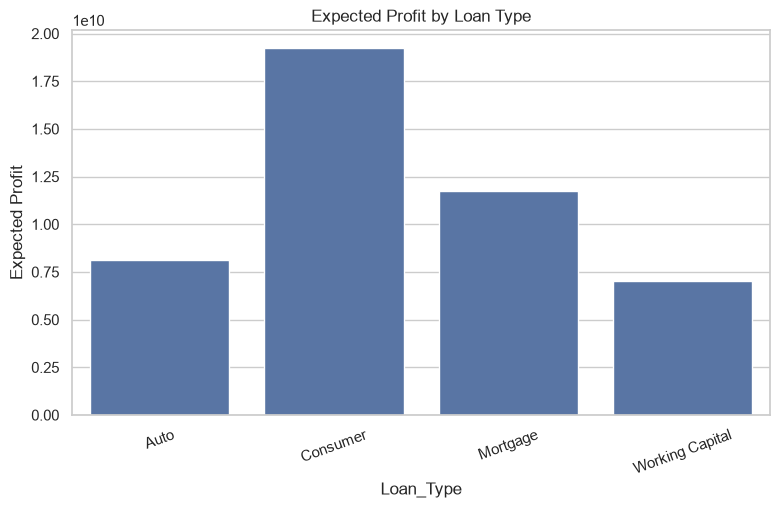

In [6]:
plt.figure(figsize=(9,5))
sns.barplot(
    data=loan_type,
    x="Loan_Type",
    y="Profit"
)
plt.title("Expected Profit by Loan Type")
plt.ylabel("Expected Profit")
plt.xticks(rotation=20)
save_plot("9-portfolio-by-loan-type.png")
plt.show()

## 10. Portfolio by Customer Segment

The same breakdown by customer segment reveals concentration risk — which customer groups a downturn would hit hardest and where provisioning pressure would appear first.


In [7]:
segment=(
    df.groupby("Customer_Segment")
      .agg(
          Loans=("Loan_ID","count"),
          EAD=("EAD","sum"),
          PD=("PD_Base","mean"),
          LGD=("LGD_Base","mean"),
          Expected_Loss=("Expected_Loss_Base","sum"),
          Profit=("Expected_Profit_Base","sum")
      )
      .reset_index()
)

display(segment.round(3))

,Customer_Segment,Loans,EAD,PD,LGD,Expected_Loss,Profit
0,Affluent,1227,1.920943e+11,0.097,0.309,5.713077e+09,1.104064e+10
1,Mass,3433,5.420190e+11,0.100,0.304,1.634986e+10,3.146774e+10
2,Priority,340,5.813037e+10,0.105,0.298,1.665083e+09,3.595279e+09


## 11. Deterministic Scenario Analysis

First, create four predefined scenarios.

Each scenario changes:

```text
PD
LGD
Interest Rate
Operating Cost
```

For example:

```text
Stress:
PD ↑
LGD ↑
Cost ↑
Rate changes
```

Then recalculate the portfolio.

In [8]:
def run_scenario(data, pd_multiplier, lgd_multiplier,
                  rate_shock, cost_multiplier):
    x=data.copy()

    x["PD_Scenario"]=(
        x["PD_Base"]*pd_multiplier
    ).clip(0,.99)

    x["LGD_Scenario"]=(
        x["LGD_Base"]*lgd_multiplier
    ).clip(0,.99)

    x["Rate_Scenario"]=(
        x["Interest_Rate"]+rate_shock
    ).clip(.01,.30)

    x["Operating_Cost_Scenario"]=(
        x["Annual_Operating_Cost"]*
        cost_multiplier
    )

    x["Expected_Loss"]=(
        x["EAD"]*
        x["PD_Scenario"]*
        x["LGD_Scenario"]
    )

    x["Interest_Income"]=(
        x["EAD"]*
        x["Rate_Scenario"]
    )

    x["Profit"]=(
        x["Interest_Income"]
        -
        x["Expected_Loss"]
        -
        x["Operating_Cost_Scenario"]
    )

    return x

In [9]:
scenario_results=[]

for _,s in scenarios.iterrows():
    x=run_scenario(
        df,
        s["PD_Multiplier"],
        s["LGD_Multiplier"],
        s["Rate_Shock"],
        s["Operating_Cost_Multiplier"]
    )

    scenario_results.append({
        "Scenario":s["Scenario"],
        "Total_EAD":x["EAD"].sum(),
        "Expected_Loss":x["Expected_Loss"].sum(),
        "Interest_Income":x["Interest_Income"].sum(),
        "Operating_Cost":x["Operating_Cost_Scenario"].sum(),
        "Profit":x["Profit"].sum()
    })

scenario_results=pd.DataFrame(scenario_results)

display(scenario_results.round(0))

,Scenario,Total_EAD,Expected_Loss,Interest_Income,Operating_Cost,Profit
0,Base,7.922436e+11,2.372802e+10,8.406185e+10,1.423017e+10,4.610366e+10
1,Optimistic,7.922436e+11,1.916038e+10,8.010063e+10,1.351866e+10,4.742160e+10
2,Mild Stress,7.922436e+11,3.262603e+10,8.802307e+10,1.536858e+10,4.002846e+10
3,Severe Stress,7.922436e+11,5.041961e+10,9.198429e+10,1.707620e+10,2.448848e+10


## 12. Scenario Profit Comparison

Portfolio profit is recomputed under each economic scenario and compared side by side. This is the first picture of how sensitive the bank's earnings are to conditions outside its control.


Saved: output/12-scenario-profit-comparison.png


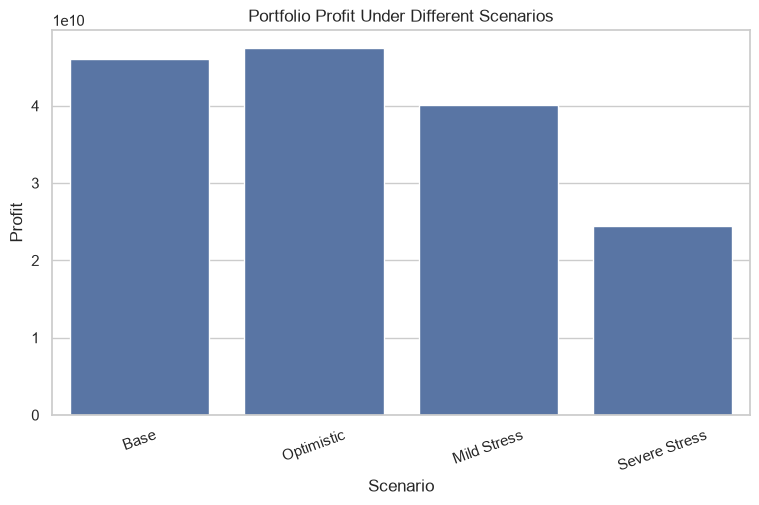

In [10]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=scenario_results,
    x="Scenario",
    y="Profit"
)

plt.title("Portfolio Profit Under Different Scenarios")
plt.ylabel("Profit")
plt.xticks(rotation=20)
save_plot("12-scenario-profit-comparison.png")
plt.show()

## 13. Scenario Loss Comparison

Expected losses per scenario are compared. The jump in loss under the downturn scenario quantifies the provisioning and capital pressure a bad economy would create.


Saved: output/13-scenario-loss-comparison.png


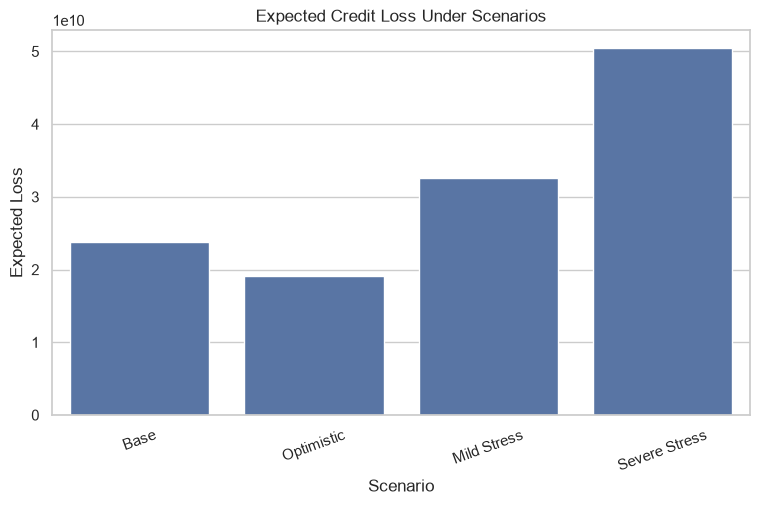

In [11]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=scenario_results,
    x="Scenario",
    y="Expected_Loss"
)

plt.title("Expected Credit Loss Under Scenarios")
plt.ylabel("Expected Loss")
plt.xticks(rotation=20)
save_plot("13-scenario-loss-comparison.png")
plt.show()

## 14. Scenario Impact vs Base

The important management question is often:

> How much does the portfolio deteriorate relative to the base case?

Calculate:

```text
Profit Impact
=
Scenario Profit
-
Base Profit
```

and:

```text
Loss Increase
=
Scenario Expected Loss
-
Base Expected Loss
```

In [12]:
base_profit=scenario_results.loc[
    scenario_results["Scenario"]=="Base",
    "Profit"
].iloc[0]

base_loss=scenario_results.loc[
    scenario_results["Scenario"]=="Base",
    "Expected_Loss"
].iloc[0]

scenario_results["Profit_Impact"]=(
    scenario_results["Profit"]-base_profit
)

scenario_results["Loss_Impact"]=(
    scenario_results["Expected_Loss"]-base_loss
)

display(
    scenario_results[
        [
            "Scenario","Profit",
            "Profit_Impact",
            "Expected_Loss",
            "Loss_Impact"
        ]
    ].round(0)
)

,Scenario,Profit,Profit_Impact,Expected_Loss,Loss_Impact
0,Base,4.610366e+10,0.000000e+00,2.372802e+10,0.000000e+00
1,Optimistic,4.742160e+10,1.317935e+09,1.916038e+10,-4.567645e+09
2,Mild Stress,4.002846e+10,-6.075204e+09,3.262603e+10,8.898009e+09
3,Severe Stress,2.448848e+10,-2.161518e+10,5.041961e+10,2.669159e+10


## 15. Segment Stress Testing

Portfolio-level results can hide concentration risk.

For example:

```text
Total portfolio looks healthy
```

while:

```text
Mortgage
    ↓
large exposure
    ↓
large stress loss
```

Therefore, run scenario analysis by:

- loan type,
- customer segment,
- branch,
- geography,
- vintage,
- risk grade.

In [13]:
stress=run_scenario(
    df,
    pd_multiplier=1.50,
    lgd_multiplier=1.15,
    rate_shock=.005,
    cost_multiplier=1.10
)

segment_stress=(
    stress.groupby("Customer_Segment")
    .agg(
        EAD=("EAD","sum"),
        Expected_Loss=("Expected_Loss","sum"),
        Profit=("Profit","sum")
    )
    .reset_index()
)

display(segment_stress.round(0))

,Customer_Segment,EAD,Expected_Loss,Profit
0,Affluent,1.920943e+11,9.855058e+09,7.508405e+09
1,Mass,5.420190e+11,2.820352e+10,2.134845e+10
2,Priority,5.813037e+10,2.872269e+09,2.582195e+09


## 16. Monte Carlo Simulation

Deterministic scenarios provide a few points.

Monte Carlo provides a distribution.

For each simulation:

```text
Random PD shock
Random LGD shock
Random rate shock
Random cost shock
        ↓
Portfolio Profit
```

Repeat:

```text
5,000 times
```

Then examine:

- mean,
- median,
- P5,
- P10,
- P25,
- P50,
- P90,
- probability of negative profit.

In [14]:
N_SIM=5000
rng=np.random.default_rng(42)
simulation_results=[]

for i in range(N_SIM):
    # Macro shocks with correlated direction
    macro=rng.normal(0,1)

    pd_shock=np.exp(
        rng.normal(
            loc=0.0+0.10*macro,
            scale=.12
        )
    )

    lgd_shock=np.exp(
        rng.normal(
            loc=0.0+0.07*macro,
            scale=.08
        )
    )

    rate_shock=rng.normal(
        loc=0.0,
        scale=.006
    )

    cost_multiplier=np.exp(
        rng.normal(
            loc=0.0+0.03*macro,
            scale=.04
        )
    )

    x=run_scenario(
        df,
        pd_multiplier=pd_shock,
        lgd_multiplier=lgd_shock,
        rate_shock=rate_shock,
        cost_multiplier=cost_multiplier
    )

    simulation_results.append({
        "Simulation":i+1,
        "Profit":x["Profit"].sum(),
        "Expected_Loss":x["Expected_Loss"].sum(),
        "Interest_Income":x["Interest_Income"].sum(),
        "PD_Multiplier":pd_shock,
        "LGD_Multiplier":lgd_shock,
        "Rate_Shock":rate_shock,
        "Cost_Multiplier":cost_multiplier
    })

sim=pd.DataFrame(simulation_results)

display(sim.head())

,Simulation,Profit,Expected_Loss,Interest_Income,PD_Multiplier,LGD_Multiplier,Rate_Shock,Cost_Multiplier
0,1,5.182758e+10,2.342249e+10,8.853279e+10,0.909986,1.084768,0.005643,0.933420
1,2,5.192842e+10,1.882767e+10,8.398199e+10,0.891476,0.890073,-0.000101,0.929427
2,3,4.412376e+10,3.041001e+10,8.942015e+10,1.198745,1.069125,0.006763,1.046114
3,4,5.454892e+10,1.984826e+10,8.823753e+10,0.959177,0.872091,0.005271,0.972606
4,5,4.604929e+10,2.336693e+10,8.332730e+10,0.904658,1.088568,-0.000927,0.977576


## 17. Monte Carlo Profit Distribution

Thousands of random draws — instead of three discrete scenarios — produce the full distribution of portfolio profit. A distribution captures tail risk that point scenarios miss.


Saved: output/17-monte-carlo-profit-distribution.png


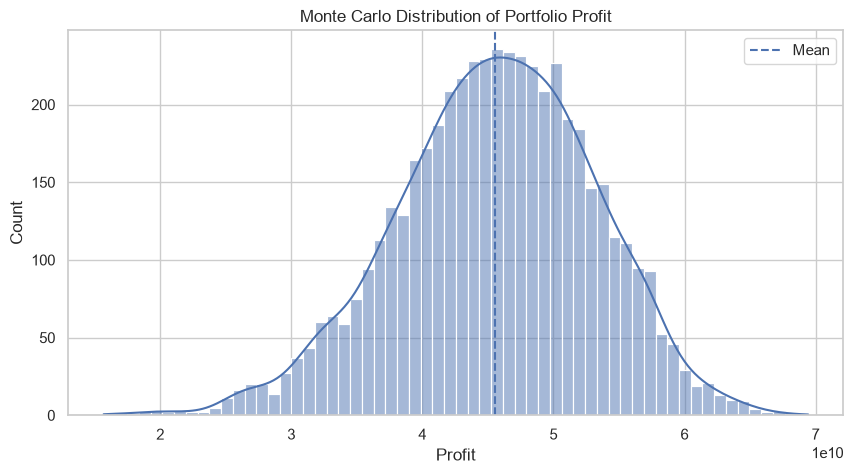

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    sim["Profit"],
    bins=60,
    kde=True
)

plt.axvline(
    sim["Profit"].mean(),
    ls="--",
    label="Mean"
)

plt.title("Monte Carlo Distribution of Portfolio Profit")
plt.xlabel("Profit")
plt.legend()
save_plot("17-monte-carlo-profit-distribution.png")
plt.show()

## 18. Monte Carlo Risk Metrics

Summary risk metrics — mean profit, volatility and low-percentile (Value-at-Risk-style) outcomes — translate the Monte-Carlo output into numbers a risk committee can set limits against.


In [16]:
risk_metrics=pd.DataFrame({
    "Metric":[
        "Mean Profit",
        "Median Profit",
        "P5 Profit",
        "P10 Profit",
        "P25 Profit",
        "P75 Profit",
        "P95 Profit",
        "Probability Profit < 0"
    ],
    "Value":[
        sim["Profit"].mean(),
        sim["Profit"].median(),
        sim["Profit"].quantile(.05),
        sim["Profit"].quantile(.10),
        sim["Profit"].quantile(.25),
        sim["Profit"].quantile(.75),
        sim["Profit"].quantile(.95),
        (sim["Profit"]<0).mean()
    ]
})

display(risk_metrics)

,Metric,Value
0,Mean Profit,4.554775e+10
1,Median Profit,4.581242e+10
2,P5 Profit,3.245038e+10
3,P10 Profit,3.569018e+10
4,P25 Profit,4.065424e+10
5,P75 Profit,5.081113e+10
6,P95 Profit,5.736432e+10
7,Probability Profit < 0,0.000000e+00


## 19. Value at Risk Style Interpretation

For simulation purposes:

```text
P5 Profit
```

means approximately:

> 5% of simulated outcomes are below this profit level.

This is useful as a downside scenario indicator.

It should not automatically be interpreted as regulatory VaR because the methodology and economic meaning differ.

## 20. Expected Shortfall

Another useful tail metric is:

```text
Average Profit among the worst 5% outcomes
```

This describes the severity of the downside tail, not only its threshold.

In [17]:
p5=sim["Profit"].quantile(.05)

expected_shortfall=sim.loc[
    sim["Profit"]<=p5,
    "Profit"
].mean()

print("P5 Profit:",round(p5))
print("Expected Shortfall (worst 5% mean):",round(expected_shortfall))

P5 Profit: 32450380644
Expected Shortfall (worst 5% mean): 28803502014


## 21. Probability of Stress

Management can define a stress threshold.

For example:

```text
Stress = profit below 90% of base profit
```

Then estimate:

```text
P(Profit < Stress Threshold)
```

This converts simulation into a risk probability.

In [18]:
stress_threshold=.90*base_profit

prob_stress=(
    sim["Profit"]<stress_threshold
).mean()

print("Base profit:",round(base_profit))
print("Stress threshold:",round(stress_threshold))
print("Probability below threshold:",
      round(prob_stress,4))

Base profit: 46103661117
Stress threshold: 41493295005
Probability below threshold: 0.2826


## 22. Sensitivity Analysis

Which assumptions drive profit the most?

Candidate drivers:

- PD multiplier
- LGD multiplier
- interest-rate shock
- operating-cost multiplier

We can estimate simple correlations between simulation inputs and portfolio profit.

In [19]:
sensitivity=sim[
    [
        "PD_Multiplier",
        "LGD_Multiplier",
        "Rate_Shock",
        "Cost_Multiplier",
        "Profit"
    ]
].corr()["Profit"].drop("Profit").sort_values()

display(sensitivity.to_frame("Correlation_with_Profit"))

,Correlation_with_Profit
PD_Multiplier,-0.695396
LGD_Multiplier,-0.597826
Cost_Multiplier,-0.424858
Rate_Shock,0.626768


Saved: output/22-sensitivity-analysis.png


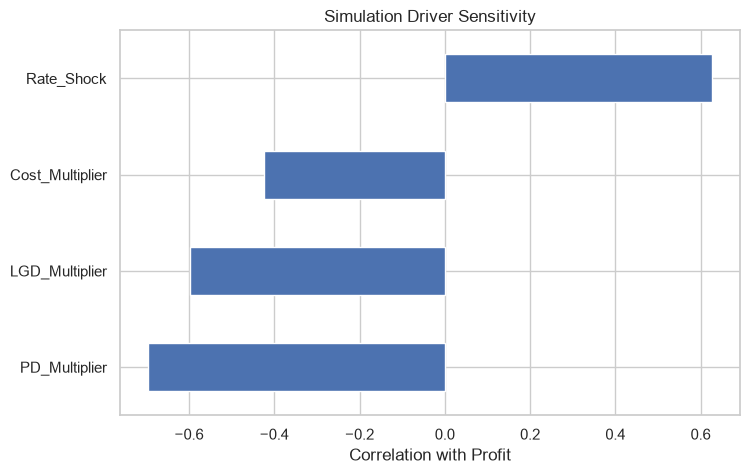

In [20]:
plt.figure(figsize=(8,5))

sensitivity.sort_values().plot(
    kind="barh"
)

plt.title("Simulation Driver Sensitivity")
plt.xlabel("Correlation with Profit")
save_plot("22-sensitivity-analysis.png")
plt.show()

## 23. Two-Way Stress Test

A useful management tool is a stress matrix.

Example:

```text
                 PD Shock
              0%    +20%    +40%    +60%

LGD  0%
     +10%
     +20%
     +30%
```

Each cell contains simulated or deterministic portfolio profit.

This helps management understand combinations of adverse conditions.

In [21]:
pd_shocks=[1.0,1.2,1.4,1.6]
lgd_shocks=[1.0,1.1,1.2,1.3]

matrix=[]

for lgd_mult in lgd_shocks:
    row=[]
    for pd_mult in pd_shocks:
        x=run_scenario(
            df,
            pd_multiplier=pd_mult,
            lgd_multiplier=lgd_mult,
            rate_shock=0,
            cost_multiplier=1
        )
        row.append(x["Profit"].sum())
    matrix.append(row)

stress_matrix=pd.DataFrame(
    matrix,
    index=[f"LGD x{v:.1f}" for v in lgd_shocks],
    columns=[f"PD x{v:.1f}" for v in pd_shocks]
)

display(stress_matrix.round(0))

,PD x1.0,PD x1.2,PD x1.4,PD x1.6
LGD x1.0,4.610366e+10,4.135806e+10,3.661245e+10,3.186685e+10
LGD x1.1,4.373086e+10,3.851069e+10,3.329053e+10,2.807036e+10
LGD x1.2,4.135829e+10,3.566361e+10,2.996894e+10,2.427426e+10
LGD x1.3,3.899132e+10,3.282325e+10,2.665518e+10,2.048710e+10


Saved: output/23-two-way-stress-test.png


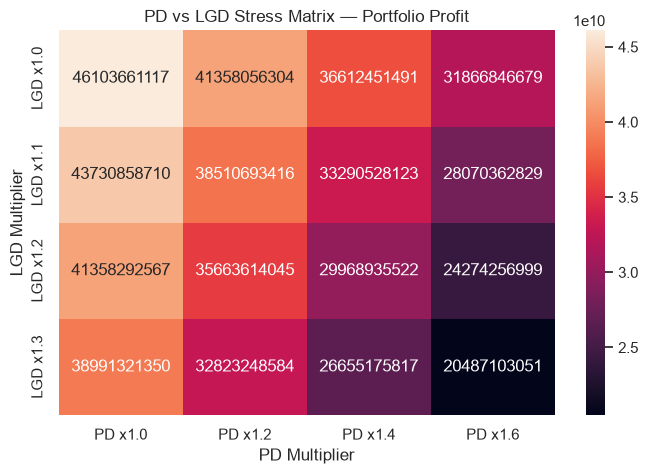

In [22]:
plt.figure(figsize=(8,5))

sns.heatmap(
    stress_matrix,
    annot=True,
    fmt=".0f"
)

plt.title("PD vs LGD Stress Matrix — Portfolio Profit")
plt.xlabel("PD Multiplier")
plt.ylabel("LGD Multiplier")
save_plot("23-two-way-stress-test.png")
plt.show()

## 24. Segment-Level Monte Carlo

A bank may want to know:

> Which customer segment contributes most to downside risk?

The simulation can be repeated at segment level.

This supports:

- portfolio concentration analysis,
- risk appetite discussions,
- product strategy,
- credit policy decisions.

In [23]:
segment_mc=[]

for i in range(1000):
    pd_mult=np.exp(rng.normal(0,.15))
    lgd_mult=np.exp(rng.normal(0,.10))
    rate_shock=rng.normal(0,.006)
    cost_mult=np.exp(rng.normal(0,.05))

    x=run_scenario(
        df,
        pd_mult,
        lgd_mult,
        rate_shock,
        cost_mult
    )

    g=x.groupby("Customer_Segment")["Profit"].sum()

    for seg,value in g.items():
        segment_mc.append({
            "Simulation":i+1,
            "Segment":seg,
            "Profit":value
        })

segment_mc=pd.DataFrame(segment_mc)

display(
    segment_mc.groupby("Segment")["Profit"]
    .agg(["mean","median","min","max"])
    .round(0)
)

,mean,median,min,max
Segment,,,,
Affluent,1.097251e+10,1.101177e+10,4.439908e+09,1.633761e+10
Mass,3.127227e+10,3.137547e+10,1.271288e+10,4.646948e+10
Priority,3.575827e+09,3.587668e+09,1.640440e+09,5.171059e+09


## 25. Scenario Decision Framework

Simulation should support a decision.

Example:

```text
Scenario
   ↓
Financial Impact
   ↓
Risk Threshold
   ↓
Management Trigger
   ↓
Action
```

Possible actions:

- tighten underwriting,
- increase collection capacity,
- adjust pricing,
- revise risk appetite,
- increase provisions,
- rebalance portfolio,
- reduce exposure to vulnerable segments.

The simulation does not choose the business policy automatically.

## 26. Simulation vs Stress Testing

They are related but not identical.

### Scenario Analysis

Explores specified assumptions.

```text
"What if PD increases 30%?"
```

### Monte Carlo Simulation

Explores a distribution of uncertain assumptions.

```text
"What range of outcomes could occur?"
```

### Stress Testing

Typically focuses on severe but plausible adverse conditions and their impact on financial resilience.

In banking, formal stress testing may involve institution-specific regulatory and risk frameworks beyond this educational notebook.

## 27. Production Architecture

```text
Core Banking
     ↓
Loan Portfolio
     ↓
Risk Models
     ↓
PD / LGD / EAD
     ↓
Scenario Engine
     ↓
Simulation Engine
     ↓
Portfolio Aggregation
     ↓
Risk Dashboard
     ↓
Management Decision
```

For production:

```text
Data Versioning
+
Model Versioning
+
Scenario Versioning
+
Audit Trail
```

are important.

## 28. Scenario Governance

Every scenario should document:

- scenario name,
- assumption owner,
- effective date,
- input variables,
- shock magnitude,
- rationale,
- model version,
- data version,
- approval status.

Avoid creating undocumented scenarios that cannot be reproduced.

## 29. Common Mistakes

1. Treating scenarios as forecasts.
2. Using unrealistic assumptions without documentation.
3. Ignoring correlations between risk factors.
4. Running simulation without validating the underlying models.
5. Reporting only average outcomes.
6. Ignoring downside percentiles.
7. Ignoring portfolio concentration.
8. Treating Monte Carlo output as certainty.
9. Mixing regulatory stress testing with simple scenario analysis.
10. Failing to version assumptions.
11. Ignoring model risk.
12. Not connecting scenarios to management actions.

## 30. Final Executive Summary

### Business Question

> **How resilient is the bank's loan portfolio under different economic and business scenarios?**

### End-to-End Workflow

```text
Portfolio Data
      ↓
Base Risk & Financial Metrics
      ↓
Scenario Assumptions
      ↓
Deterministic Scenario Analysis
      ↓
Stress Testing
      ↓
Monte Carlo Simulation
      ↓
Outcome Distribution
      ↓
Tail Risk Metrics
      ↓
Sensitivity Analysis
      ↓
Management Decision
```

### Key distinction

```text
Prediction
→ What is likely to happen?

Optimization
→ What should we do?

Simulation
→ What could happen under different assumptions?
```

Simulation is particularly useful for:

- credit portfolio stress,
- liquidity scenarios,
- interest-rate scenarios,
- deposit/run-off scenarios,
- collection scenarios,
- revenue scenarios,
- operational risk scenarios,
- capital planning,
- strategic banking planning.

## 31. Save Outputs

All key result tables and figures are saved into the local `output/` folder, so results survive after the kernel is restarted and can be shared without re-running the notebook.


In [24]:
scenario_results.to_csv(OUTPUT_DIR / "scenario_results.csv", index=False)
print("Saved:", OUTPUT_DIR / "scenario_results.csv")
risk_metrics.to_csv(OUTPUT_DIR / "monte_carlo_risk_metrics.csv", index=False)
print("Saved:", OUTPUT_DIR / "monte_carlo_risk_metrics.csv")


# List everything that was written to output/
for _p in sorted(OUTPUT_DIR.iterdir()):
    print(" ", _p)


Saved: output/scenario_results.csv
Saved: output/monte_carlo_risk_metrics.csv
  output/12-scenario-profit-comparison.png
  output/13-scenario-loss-comparison.png
  output/17-monte-carlo-profit-distribution.png
  output/22-sensitivity-analysis.png
  output/23-two-way-stress-test.png
  output/9-portfolio-by-loan-type.png
  output/monte_carlo_risk_metrics.csv
  output/scenario_results.csv
